## Analysis of Socioeconomic Indicators

This notebook analyzes the cleaned datasets stored in MongoDB. The datasets include:

- birth rate by region and year
- gross regional product (GRP)
- GRP per capita
- employment rate
- housing price index (HPI)

The goal is to explore relationships between these indicators and identify patterns across regions and over time.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pymongo import MongoClient

client = MongoClient("mongodb://localhost:27017/")
db = client["mongo_db"]


def load_collection(name):
    df = pd.DataFrame(list(db[name].find()))
    if "_id" in df.columns:
        df = df.drop(columns="_id")
    return df

In [2]:
birthrate = load_collection("clean_birthrate")
grp = load_collection("clean_GRP")
grp_pc = load_collection("clean_GRP_per_capita")

print(birthrate.head())
print(grp.head())

  NUTS-Code  year  birth_rate
0     AT111  2002       7.260
1     AT111  2003       6.693
2     AT111  2004       7.744
3     AT111  2005       7.265
4     AT111  2006       6.942
  NUTS-Code            Region  year    GRP
0     AT111  Mittelburgenland  2000  572.0
1     AT111  Mittelburgenland  2001  611.0
2     AT111  Mittelburgenland  2002  599.0
3     AT111  Mittelburgenland  2003  636.0
4     AT111  Mittelburgenland  2004  645.0


## Merging Birth Rate and GRP Data

To analyze the relationship between economic output and birth rate, the two datasets are merged using:

- NUTS-Code (region)
- year (time)

This creates a combined dataset with both variables for each region-year observation.

In [3]:
merged = birthrate.merge(
    grp,
    on=["NUTS-Code", "year"],
    how="inner"
)

print(merged.head())
print(merged.shape)

  NUTS-Code  year  birth_rate            Region    GRP
0     AT111  2002       7.260  Mittelburgenland  599.0
1     AT111  2003       6.693  Mittelburgenland  636.0
2     AT111  2004       7.744  Mittelburgenland  645.0
3     AT111  2005       7.265  Mittelburgenland  666.0
4     AT111  2006       6.942  Mittelburgenland  703.0
(770, 5)


In [4]:
correlation = merged["birth_rate"].corr(merged["GRP"])
print("Correlation between birth rate and GRP:", correlation)

Correlation between birth rate and GRP: 0.32538932592144815


## First Visualization: Birth Rate vs GRP

A scatter plot is used to visualize the relationship between gross regional product (GRP) and birth rate.

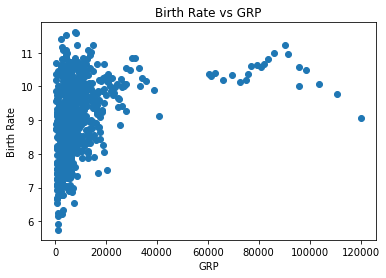

In [5]:
plt.figure()
plt.scatter(merged["GRP"], merged["birth_rate"])
plt.xlabel("GRP")
plt.ylabel("Birth Rate")
plt.title("Birth Rate vs GRP")
plt.show()

## Observation

The scatter plot shows that the data points appear compressed along the horizontal axis. This is due to the large difference in scale between the variables:

- GRP values range from a few hundred to over 100,000
- Birth rates range only between approximately 5 and 12

This large variation in GRP is expected, as GRP represents the total economic output of a region. Larger regions with higher population and economic activity naturally have much higher GRP values than smaller regions.

However, this also highlights a conceptual issue: GRP is an absolute measure, while birth rate is a relative measure (per 1,000 people). As a result, comparing these two variables directly is not meaningful.

For a more appropriate analysis, GRP per capita will be used in the following step, as it provides a normalized measure of economic output that allows for better comparison across regions.

## Using GRP per Capita for Analysis

To obtain a more meaningful comparison, GRP per capita is used instead of total GRP. This normalizes economic output by population size and allows for better comparison between regions of different sizes.

In [6]:
merged_pc = birthrate.merge(
    grp_pc,
    on=["NUTS-Code", "year"],
    how="inner"
)

print(merged_pc.head())
print(merged_pc.shape)

  NUTS-Code  year  birth_rate            Region  GRP_per_capita
0     AT111  2002       7.260  Mittelburgenland         15900.0
1     AT111  2003       6.693  Mittelburgenland         16900.0
2     AT111  2004       7.744  Mittelburgenland         17200.0
3     AT111  2005       7.265  Mittelburgenland         17800.0
4     AT111  2006       6.942  Mittelburgenland         18800.0
(770, 5)


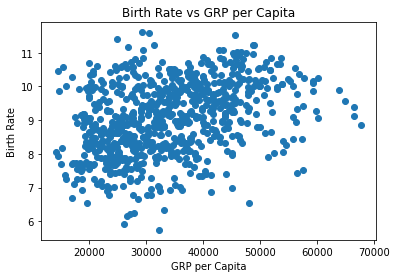

In [7]:
plt.figure()
plt.scatter(merged_pc["GRP_per_capita"], merged_pc["birth_rate"])
plt.xlabel("GRP per Capita")
plt.ylabel("Birth Rate")
plt.title("Birth Rate vs GRP per Capita")
plt.show()

In [8]:
correlation = merged_pc["birth_rate"].corr(merged_pc["GRP_per_capita"])
print("Correlation:", correlation)

Correlation: 0.3579988828395577


## Observation

The correlation between birth rate and GRP per capita is positive but moderate (approximately 0.36).

This suggests that regions with higher economic output per person tend to have slightly higher birth rates. However, the relationship is not strong, indicating that economic conditions alone do not fully explain differences in birth rates.

While there appears to be a tendency for more economically developed regions to have somewhat higher birth rates in this dataset, other factors—such as social structure, urbanization, or policy—are likely to play an important role.

Overall, GRP per capita shows some association with birth rate, but it is not a strong predictor on its own.

## Development Over Time

To better understand the relationship between economic conditions and birth rates, the data is aggregated by year. This allows us to observe general trends over time across all regions.

In [9]:
yearly = merged_pc.groupby("year").agg({
    "birth_rate": "mean",
    "GRP_per_capita": "mean"
}).reset_index()

print(yearly.head())

   year  birth_rate  GRP_per_capita
0  2002    9.422114    23985.714286
1  2003    9.212543    24508.571429
2  2004    9.402200    25477.142857
3  2005    9.205971    26614.285714
4  2006    9.118657    27994.285714


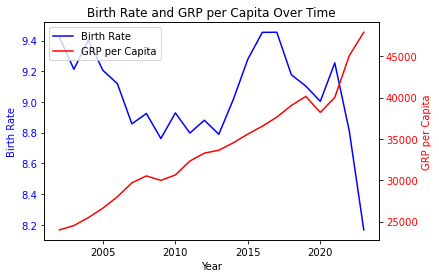

In [10]:
fig, ax1 = plt.subplots()

# Birth rate (left axis)
line1 = ax1.plot(
    yearly["year"],
    yearly["birth_rate"],
    label="Birth Rate",
    color="blue"
)
ax1.set_xlabel("Year")
ax1.set_ylabel("Birth Rate", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# GRP per capita (right axis)
ax2 = ax1.twinx()
line2 = ax2.plot(
    yearly["year"],
    yearly["GRP_per_capita"],
    label="GRP per Capita",
    color="red"
)
ax2.set_ylabel("GRP per Capita", color="red")
ax2.tick_params(axis="y", labelcolor="red")

# Combined legend
lines = line1 + line2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left")

plt.title("Birth Rate and GRP per Capita Over Time")
plt.show()

## Housing Prices and Birth Rate

In addition to economic output, housing prices may influence demographic behavior. Higher housing costs can affect decisions related to family formation and childbearing.

To explore this relationship, the birth rate is analyzed in relation to the Housing Price Index (HPI). Unlike GRP, HPI reflects living costs and housing affordability, which may have a more direct impact on individuals.

Since HPI is only available at the national level, the analysis focuses on the relationship over time.

In [11]:
hpi = load_collection("clean_HPI")

print(hpi.head())

    Period           HPI_type     HPI
0  2010 Q1  Bestehende Häuser   96.51
1  2010 Q2  Bestehende Häuser  100.95
2  2010 Q3  Bestehende Häuser  100.56
3  2010 Q4  Bestehende Häuser  101.98
4  2011 Q1  Bestehende Häuser  102.24


In [12]:
hpi_yearly = hpi.copy()

# extract year from "Period"
hpi_yearly["year"] = hpi_yearly["Period"].str.extract(r"(\d{4})").astype("Int64")

# average all HPI values per year
hpi_yearly = hpi_yearly.groupby("year")["HPI"].mean().reset_index()

print(hpi_yearly.head())

   year       HPI
0  2010   99.9995
1  2011  105.3555
2  2012  112.2235
3  2013  117.8505
4  2014  122.3435


In [13]:
birthrate_yearly = birthrate.groupby("year")["birth_rate"].mean().reset_index()

print(birthrate_yearly.head())

   year  birth_rate
0  2002    9.422114
1  2003    9.212543
2  2004    9.402200
3  2005    9.205971
4  2006    9.118657


In [14]:
merged_hpi = birthrate_yearly.merge(
    hpi_yearly,
    on="year",
    how="inner"
)

print(merged_hpi.head())
print(merged_hpi.shape)

   year  birth_rate       HPI
0  2010    8.928829   99.9995
1  2011    8.797229  105.3555
2  2012    8.880657  112.2235
3  2013    8.789514  117.8505
4  2014    9.016571  122.3435
(15, 3)


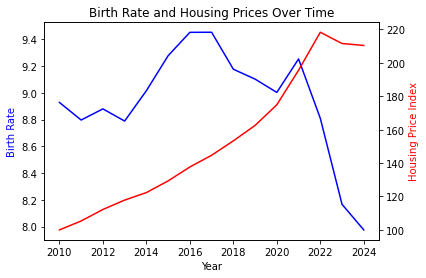

In [15]:
fig, ax1 = plt.subplots()

# birth rate
ax1.plot(merged_hpi["year"], merged_hpi["birth_rate"], color="blue")
ax1.set_xlabel("Year")
ax1.set_ylabel("Birth Rate", color="blue")

# HPI
ax2 = ax1.twinx()
ax2.plot(merged_hpi["year"], merged_hpi["HPI"], color="red")
ax2.set_ylabel("Housing Price Index", color="red")

plt.title("Birth Rate and Housing Prices Over Time")
plt.show()

In [16]:
hpi_corr = merged_hpi["birth_rate"].corr(merged_hpi["HPI"])
print("Correlation (Birth Rate vs HPI):", hpi_corr)

Correlation (Birth Rate vs HPI): -0.422561713540666


## Observation

The time series shows that housing prices have increased steadily over the observed period, while birth rates remain relatively stable or slightly declining.

The correlation between birth rate and housing prices is moderately negative (approximately -0.42). This suggests that higher housing prices are associated with lower birth rates.

Compared to the previous analyses using GRP and GRP per capita, this relationship is stronger. This indicates that housing costs may have a more direct influence on demographic behavior than general economic output.

However, the relationship is still not strong enough to fully explain variations in birth rates. Other factors—such as social conditions, policies, and cultural influences—are likely also important.

Overall, housing prices appear to be a more relevant factor than general economic indicators, but not a decisive one on their own.